### 회귀분석

### 여러 변수와 청년 순이동률 회귀모델 분석

In [10]:
import pandas as pd
import numpy as np
import scipy

In [11]:
data = pd.read_csv('../../data/vif_corr_reduction_data.csv')

In [12]:
data['Y']

0      0.0
1      3.0
2      4.9
3      0.3
4      2.3
      ... 
911   -8.6
912   -4.7
913    1.3
914   -5.7
915   -5.1
Name: Y, Length: 916, dtype: float64

In [13]:
data.loc[:,['Y','CMR','INDUSTRIAL_AREA', 'SELF_FINANCE']]

,Y,CMR,INDUSTRIAL_AREA,SELF_FINANCE
0,0.0,390,0.000000,47.0
1,3.0,540,0.000000,53.5
2,4.9,540,0.000000,39.3
3,0.3,540,1.217876,32.7
4,2.3,480,0.000000,26.2
...,...,...,...,...
911,-8.6,260,4.288677,7.0
912,-4.7,290,5.356256,7.7
913,1.3,270,0.000000,8.1
914,-5.7,240,4.659090,7.9


In [14]:
data.columns

Index(['SERVICE_BUSINESS_COUNT', 'TRANSPORT_BUSINESS_COUNT',
       'MANUFACTURING_BUSINESS_COUNT', 'YTH_EMP_RT', 'INFECT_DIS_CT',
       'TRAFFIC_DTH_CT', 'T_SUICIDE_RT_100K', 'CLIMATE_DMG_IMPACT',
       'TRAFFIC_ACC_PER_100K', 'FIRE_ACC_PER_100K', 'FIRE_DTH_CT', 'FIRE_DMG',
       'TEACHERS', 'UNIVERSITIES', 'UNIVERSITY_ADMISSION_RATE',
       'KINDERGARTEN_TEACHERS', 'STUDENTS_PER_HIGH_CLASS', 'PRIVATE_ACADEMIES',
       'MAX_TEMP', 'MIN_TEMP', 'AVG_WIND_SPD', 'MAX_GUST_SPD',
       'MAX_GUST_DIR_DEG', 'TOTAL_RAIN', 'HOSPITAL_COUNT', 'WELFARE_FACILITY',
       'PHC_CNT', 'DOCTORS', 'CLINIC', 'GEN_HOSP', 'BED_TOTAL',
       'HIGH_RISK_DRINK_RT', 'WELFARE_RATIO', 'STRESS_AWARE_SOCIAL_PROT',
       'SELF_HEALTH_AWARE_RT', 'GENDER_RATIO', 'FOREIGNERS', 'SELF_FINANCE',
       'CMR', 'LAND_AREA', 'TFR', 'SINGLE_HOUSEHOLD_RATIO', 'COMMERCIAL_AREA',
       'INDUSTRIAL_AREA', 'CAR_REGISTRATION_PER_CAPTICA', 'RENTAL_NATIONAL',
       'RENTAL_PERMANENT', 'RENTAL_HAPPY', 'WATER_SUPPLY_RATE', '

In [15]:
x = data.copy()
x1 = x.drop('Y', axis=1)
x1 = x.loc[:, ['CMR','INDUSTRIAL_AREA', 'SELF_FINANCE']]
x2 = x.loc[:, ['CMR','INDUSTRIAL_AREA', 'SELF_FINANCE','MIN_TEMP']]
y = data.copy()
y1 = y.loc[:,'Y']

## 모델 회귀식
$${청년순이동률}_{t} = \beta_1 \cdot {조혼인률}_{t} + \beta_2 \cdot {공업지역 면적}_{t} + \beta_3 \cdot {재정자립도}_{t} + \beta_4 \cdot {최저기온}_t + \epsilon_{it} $$

$${청년순이동률}_{t} = \beta_1 \cdot {조혼인률}_{t} + \beta_2 \cdot {공업지역 면적}_{t} + \beta_3 \cdot {재정자립도}_{t} + \epsilon_{it} $$

In [16]:
import statsmodels.api as sm

In [17]:
## 각각 변수별로 제한하기
cmr = x.loc[:, 'CMR']

model_cmr = sm.OLS(y1, cmr)
result_cmr = model_cmr.fit()

print(result_cmr.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.075
Model:                            OLS   Adj. R-squared (uncentered):              0.074
Method:                 Least Squares   F-statistic:                              74.39
Date:                Thu, 04 Sep 2025   Prob (F-statistic):                    2.80e-17
Time:                        15:03:12   Log-Likelihood:                         -2766.8
No. Observations:                 916   AIC:                                      5536.
Df Residuals:                     915   BIC:                                      5540.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [18]:
## 각각 변수별로 제한하기
ind = x.loc[:, 'INDUSTRIAL_AREA']

model_ind = sm.OLS(y1, ind)
result_ind = model_ind.fit()

print(result_ind.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.389
Model:                            OLS   Adj. R-squared (uncentered):              0.388
Method:                 Least Squares   F-statistic:                              582.9
Date:                Thu, 04 Sep 2025   Prob (F-statistic):                   4.85e-100
Time:                        15:03:12   Log-Likelihood:                         -2576.8
No. Observations:                 916   AIC:                                      5156.
Df Residuals:                     915   BIC:                                      5160.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

In [19]:
## 각각 변수별로 제한하기
sfi = x.loc[:, 'SELF_FINANCE']

model_sfi = sm.OLS(y1, sfi)
result_sfi = model_sfi.fit()

print(result_sfi.summary())

                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):              0.011
Method:                 Least Squares   F-statistic:                              11.16
Date:                Thu, 04 Sep 2025   Prob (F-statistic):                    0.000871
Time:                        15:03:12   Log-Likelihood:                         -2797.0
No. Observations:                 916   AIC:                                      5596.
Df Residuals:                     915   BIC:                                      5601.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

변수별로 제한할 때, 설명력이 매우 낮게나온 것을 확인하였습니다.

In [20]:
## 상수항 추가
x1_sm = sm.add_constant(x1)

model_sm = sm.OLS(y1, x1_sm)
result_sm = model_sm.fit()

## 결과 요약
print(result_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     484.1
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          4.26e-188
Time:                        15:03:12   Log-Likelihood:                -2263.6
No. Observations:                 916   AIC:                             4535.
Df Residuals:                     912   BIC:                             4554.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -12.4648      0.488    -

In [21]:
## 상수항 추가
x2_sm = sm.add_constant(x2)

model_sm2 = sm.OLS(y1, x2_sm)
result_sm2 = model_sm2.fit()

## 결과 요약
print(result_sm2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     364.4
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          2.64e-187
Time:                        15:03:12   Log-Likelihood:                -2262.2
No. Observations:                 916   AIC:                             4534.
Df Residuals:                     911   BIC:                             4559.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -13.0396      0.600    -

### 정규성 가정 확인

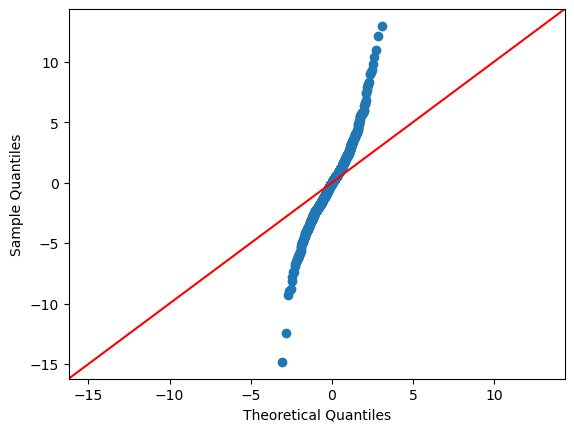

In [22]:
import matplotlib.pyplot as plt
resids = result_sm.resid


## q-q plot
sm.qqplot(resids, line='45')
plt.show()


In [23]:
y1np = np.array(y1)

In [24]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
x_trans = pt.fit_transform(x2)
y_trans = pt.fit_transform(y1np.reshape(-1,1))


### cmr
cmr_trans = pt.fit_transform(np.array(cmr).reshape(-1,1))

### ind
ind_trans = pt.fit_transform(np.array(ind).reshape(-1,1))

### sfi
sfi_trans = pt.fit_transform(np.array(sfi).reshape(-1,1))

In [25]:
x_trans = pd.DataFrame(x_trans, columns=x2.columns)

In [26]:
## 상수항 추가
x_trans_sm = sm.add_constant(x_trans)

model_trans_sm = sm.OLS(y_trans, x_trans_sm)
result_trans_sm = model_trans_sm.fit()

## 결과 요약
print(result_trans_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.632
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     391.7
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          3.25e-196
Time:                        15:03:13   Log-Likelihood:                -841.45
No. Observations:                 916   AIC:                             1693.
Df Residuals:                     911   BIC:                             1717.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -8.327e-17      0.020  -4.

## 데이터 변환 후 개별 변수 단순선형회귀

In [27]:
## 상수항 추가
cmr_trans_sm = sm.add_constant(cmr_trans)
model_trans_cmr = sm.OLS(y_trans, cmr_trans_sm)
result_trans_cmr = model_trans_cmr.fit()

ind_trans_sm = sm.add_constant(ind_trans)
model_trans_ind = sm.OLS(y_trans, ind_trans_sm)
result_trans_ind = model_trans_ind.fit()

sfi_trans_sm = sm.add_constant(sfi_trans)
model_trans_sfi = sm.OLS(y_trans, sfi_trans_sm)
result_trans_sfi = model_trans_sfi.fit()


## 결과 요약
print(result_trans_cmr.summary())
print("="*100)
print(result_trans_ind.summary())
print("="*100)
print(result_trans_sfi.summary())



                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.550
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     1117.
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          1.10e-160
Time:                        15:03:13   Log-Likelihood:                -933.97
No. Observations:                 916   AIC:                             1872.
Df Residuals:                     914   BIC:                             1882.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.153e-17      0.022  -3.67e-15      1.0

### 데이터 변환 후 정규성 가정 확인

y, x 모두 yeo-johnson 변환(box-cox 개선) 수행시 q-q plot 상으로 정규성을 따르는 것으로 보입니다.

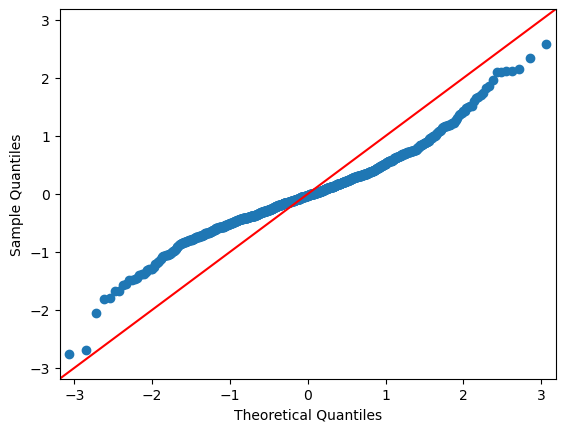

In [28]:
import matplotlib.pyplot as plt
resids = result_trans_sm.resid


## q-q plot
sm.qqplot(resids, line='45')
plt.show()


### 등분산성 가정 확인

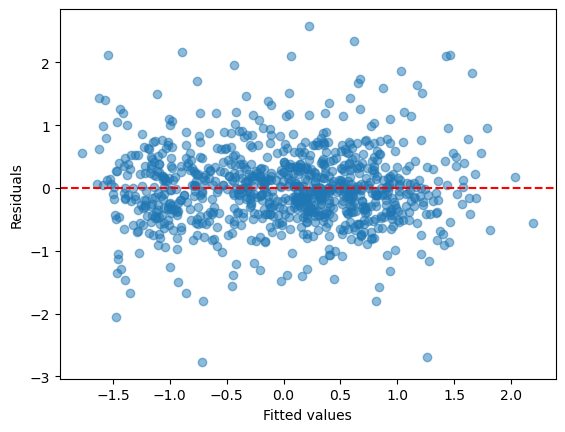

In [29]:
## 예측값과 잔차
fitted = result_trans_sm.fittedvalues
residuals = resids

plt.scatter(fitted, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

Residuals plot을 확인해보니, 등분산성도 잘 만족하고 있다.

In [31]:
df = data.copy()

In [32]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import PowerTransformer

# === 0) 데이터 준비 ===
y = df['Y'].to_numpy().reshape(-1, 1)
X = df[['CMR','INDUSTRIAL_AREA','SELF_FINANCE','MIN_TEMP']].copy()  # 필요한 컬럼
X = sm.add_constant(X)  # 상수항

# === 1) Yeo–Johnson 변환 (Y만) ===
# standardize=False 로 두면 변환-역변환이 직관적입니다.
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
y_star = pt_y.fit_transform(y).ravel()
print("Yeo–Johnson lambda for Y:", float(pt_y.lambdas_))

# === 2) 변환된 Y*로 OLS 적합 ===
model = sm.OLS(y_star, X).fit(cov_type='HC3')  # 로버스트 SE 권장
print(model.summary())

# === 3) 예측값을 '원래 Y 스케일'로 역변환 ===
yhat_star = model.predict(X)                   # 변환 스케일에서의 예측
yhat = pt_y.inverse_transform(yhat_star.to_numpy().reshape(-1,1)).ravel()  # 역변환
df_out = pd.DataFrame({'Y_true': df['Y'], 'Yhat': yhat})
df_out.head()

# === 4) 단일 변수 변화에 따른 '원래 Y' 변화량 시뮬레이션 함수 ===
def effect_on_Y_original_scale(model, pt_y, X_base: pd.Series, var: str, step: float = 1.0):
    """
    model : statsmodels 결과 (Y* 기준)
    pt_y  : PowerTransformer (Yeo–Johnson, Y 기준)
    X_base: 기준 시나리오의 설명변수 값들 (const 포함)
    var   : 변화시킬 변수명 (예: 'CMR')
    step  : var를 얼마나 변화시킬지 (단위)
    return: (Y_before, Y_after, deltaY) 모두 '원래 Y 스케일'
    """
    assert 'const' in X_base.index, "X_base에는 const가 포함되어야 합니다."
    X1 = X_base.copy()
    X2 = X_base.copy()
    X2[var] = X2[var] + step

    # 변환 스케일에서 예측
    y1_star = float(np.dot(X1.values, model.params))
    y2_star = float(np.dot(X2.values, model.params))

    # 원래 스케일로 역변환
    y1 = float(pt_y.inverse_transform(np.array([[y1_star]])))
    y2 = float(pt_y.inverse_transform(np.array([[y2_star]])))
    return y1, y2, (y2 - y1)

# === 5) 기준 시나리오 설정 (예: 각 설명변수의 중앙값) ===
X_med = pd.Series(index=X.columns, dtype=float)
for c in X.columns:
    X_med[c] = X[c].median() if c != 'const' else 1.0

# 예시: CMR을 1 단위 올렸을 때 원래 Y가 얼마나 변하는지
y_before, y_after, dY = effect_on_Y_original_scale(model, pt_y, X_med, var='CMR', step=1.0)
print(f"[CMR +1] Y (original) {y_before:.3f} → {y_after:.3f}  ΔY = {dY:.3f}")

# 다른 변수도 같은 방식으로:
for v in ['INDUSTRIAL_AREA','SELF_FINANCE','MIN_TEMP']:
    y0, y1, dy = effect_on_Y_original_scale(model, pt_y, X_med, var=v, step=1.0)
    print(f"[{v} +1] ΔY ≈ {dy:.3f}  (기준: 각 변수 중앙값)")

Yeo–Johnson lambda for Y: 0.9699497720868523
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     299.9
Date:                Thu, 04 Sep 2025   Prob (F-statistic):          1.64e-164
Time:                        15:03:27   Log-Likelihood:                -2278.2
No. Observations:                 916   AIC:                             4566.
Df Residuals:                     911   BIC:                             4590.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

C:\Users\user\AppData\Local\Temp\ipykernel_21600\246965353.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Yeo–Johnson lambda for Y:", float(pt_y.lambdas_))
C:\Users\user\AppData\Local\Temp\ipykernel_21600\246965353.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y1 = float(pt_y.inverse_transform(np.array([[y1_star]])))
C:\Users\user\AppData\Local\Temp\ipykernel_21600\246965353.py:48: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y2 = float(pt_y.in

변환 후 각각을 해석합니다.
```
[CMR +1] Y (original) -2.706 → -2.677  ΔY = 0.029
[INDUSTRIAL_AREA +1] ΔY ≈ -0.498 
[SELF_FINANCE +1] ΔY ≈ 0.060 
[MIN_TEMP +1] ΔY ≈ -0.036 
```